In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib_venn import venn3, venn3_circles, venn3_unweighted

In [8]:
# Paths to your three CSV files (metaproteins with variance explained >0.2)
file1 = "IBDvsHealthy.csv"
file2 = "UCvsHealthy.csv"
file3 = "CDvsHealthy.csv"
file4 = "UCvsCD.csv"

# path to annotation data
taxonomy_file = "merged_df.csv"
species_col = "species"
superkingdom_col = "task_1::Taxonomic_Annotation_Task_1::superkingdom"

# load data
df1 = pd.read_csv(file1, sep=",")
df1 = df1.astype({"species":"str"})
#df1 [["Meta-Protein","ID"]] = df1.species.str.split(expand=True)
df2 = pd.read_csv(file2, sep=",")
df2 = df2.astype({"species":"str"})
#df2 [["Meta-Protein","ID"]] = df2.species.str.split(expand=True)
df3 = pd.read_csv(file3, sep=",")
df3 = df3.astype({"species":"str"})
df4 = pd.read_csv(file4, sep=",")
df4 = df4.astype({"species":"str"})
#df3 [["Meta-Protein","ID"]] = df3.species.str.split(expand=True)
taxonomy = pd.read_csv(taxonomy_file, sep = ";", usecols=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26])
taxonomy = taxonomy.astype({'GroupID':'int'})
taxonomy = taxonomy.astype({'GroupID':'str'})

In [9]:
# merge annotation data and output from variance analysis (metaproteins with variance explained >0.2)
df1 = df1.merge(taxonomy, left_on="species", right_on= "GroupID" ,how="left")
df1.to_csv("IBDvsHealthy_annotated.csv", sep = ";")
df2 = df2.merge(taxonomy, left_on="species", right_on= "GroupID", how="left")
df2.to_csv("UCvsHealthy_annotated.csv", sep = ";")
df3 = df3.merge(taxonomy, left_on="species", right_on= "GroupID", how="left")
df3.to_csv("CDvsHealthy_annotated.csv", sep = ";")
df4 = df4.merge(taxonomy, left_on="species", right_on= "GroupID", how="left")
df4.to_csv("UCvsCD_annotated.csv", sep = ";")

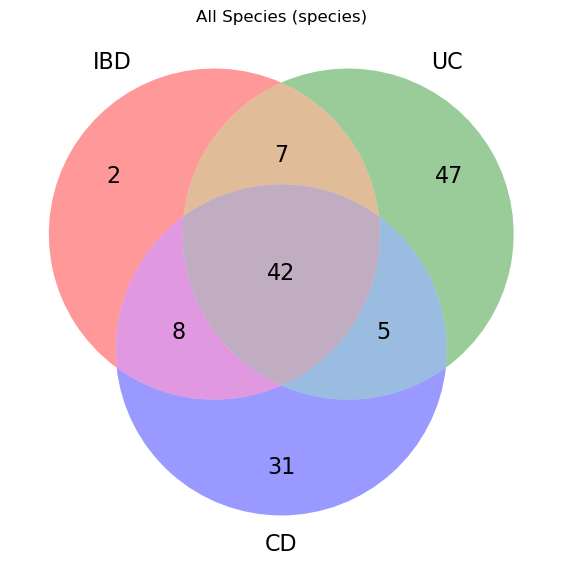

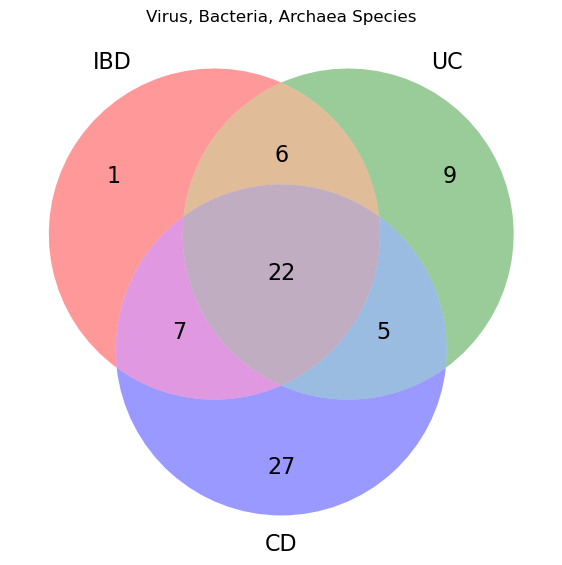

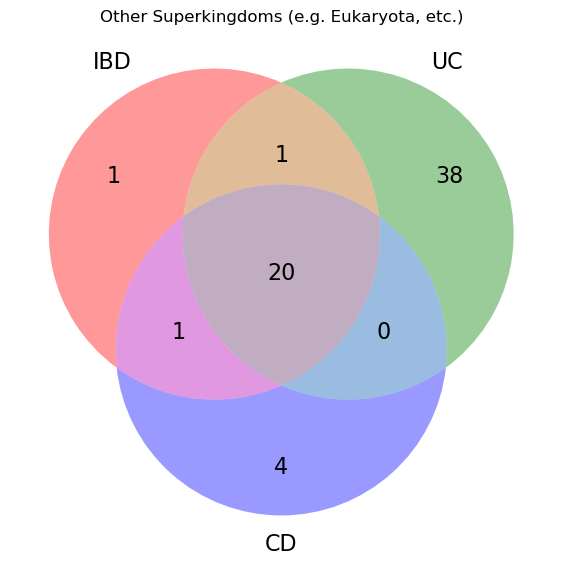

In [30]:
# create sets
set_all_1 = set(df1[species_col].dropna().unique())
set_all_2 = set(df2[species_col].dropna().unique())
set_all_3 = set(df3[species_col].dropna().unique())

# filter for Superkingdoms
target_superkingdoms = {"Virus", "Bacteria", "Archaea"}

set_target_1 = set(df1.loc[df1[superkingdom_col].isin(target_superkingdoms), species_col])
set_target_2 = set(df2.loc[df2[superkingdom_col].isin(target_superkingdoms), species_col])
set_target_3 = set(df3.loc[df3[superkingdom_col].isin(target_superkingdoms), species_col])

# filter for Non-target Superkingdoms (Others) ---
set_other_1 = set(df1.loc[~df1[superkingdom_col].isin(target_superkingdoms), species_col])
set_other_2 = set(df2.loc[~df2[superkingdom_col].isin(target_superkingdoms), species_col])
set_other_3 = set(df3.loc[~df3[superkingdom_col].isin(target_superkingdoms), species_col])

# plot function
def plot_venn(set1, set2, set3, title):
    plt.figure(figsize=(7, 7))
    out = venn3_unweighted([set1, set2, set3], set_labels=("IBD", "UC", "CD")) #venn3_circles / venn3
    plt.title(title)
    for text in out.set_labels:
        text.set_fontsize(16)
    for text in out.subset_labels:
        text.set_fontsize(16)
    plt.savefig(fname=title+".png")
    plt.show()

# plotting
plot_venn(set_all_1, set_all_2, set_all_3,
          f"All Species ({species_col})")

plot_venn(set_target_1, set_target_2, set_target_3,
          "Virus, Bacteria, Archaea Species")


plot_venn(set_other_1, set_other_2, set_other_3,
          "Other Superkingdoms (e.g. Eukaryota, etc.)")